## Chat Message Memory
- We need to store the historical chat messages in a efficient way
- It wraps another Runnable and manages the chat message history for it.
- Specifically, it loads previous messages in the conversation BEFORE passing it to the Runnable, and it saves the generated response as a message AFTER calling the runnable.
-  This class also enables multiple conversations by saving each conversation with a session_id
- it then expects a `session_id` to be passed in the config when calling the runnable, and uses that to look up the relevant conversation history

In [1]:
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

True

In [2]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(temperature=0, model_name ="gpt-4o-mini")

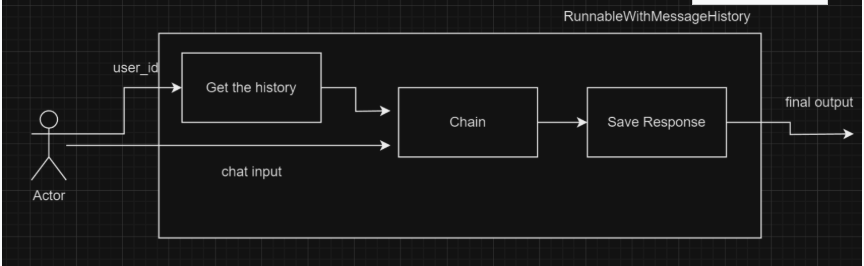

In [3]:
from langchain_core.prompts import (
                                        SystemMessagePromptTemplate,
                                        HumanMessagePromptTemplate,
                                        ChatPromptTemplate
)

from langchain_core.output_parsers import StrOutputParser

template = ChatPromptTemplate.from_template("{prompt}")
chain = template | llm | StrOutputParser()

about= "My name is Adithya Adiraju. I work for Nielsen IQ GFK. "
chain.invoke({"prompt": about})

"Hello, Adithya Adiraju! It's great to meet you. How can I assist you today?"

In [4]:
prompt = "What is my name?"
chain.invoke({'prompt': prompt})

"I'm sorry, but I don't have access to personal information about you unless you share it with me. How can I assist you today?"

In [5]:
prompt = "Where exactly Adithya Adiraju works?"
chain.invoke({'prompt': prompt})

"I'm sorry, but I can't provide personal information about individuals unless it is publicly available and widely known. If Adithya Adiraju is a public figure, you might find information about their work through a search engine or their official social media profiles."

### Runnable With Message History

In order to properly set this up there are two main things to consider:
- How to store and load messages?
- What is the underlying Runnable you are wrapping and what are its inputs/outputs?


In [6]:
from langchain_core.prompts import (
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    ChatPromptTemplate
)

from langchain_core.output_parsers import StrOutputParser

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_community.chat_message_histories import SQLChatMessageHistory

In [7]:
def get_session_history(session_id):
    return SQLChatMessageHistory(session_id,"sqlite:///chat_history.db")

In [8]:
runnable_with_history = RunnableWithMessageHistory(chain, get_session_history)

In [9]:
user_id = 'adithyad'
history = get_session_history(user_id)

history.get_messages()

C:\Users\adira\AppData\Local\Temp\ipykernel_21516\3619568840.py:2: LangChainDeprecationWarning: `connection_string` was deprecated in LangChain 0.2.2 and will be removed in 1.0. Use connection instead.
  history = get_session_history(user_id)


[HumanMessage(content='My name is Adithya Adiraju. I work for ATX Labs. ', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Hello, Adithya Adiraju! It's great to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="what's my name", additional_kwargs={}, response_metadata={}),
 AIMessage(content='Your name is Adithya Adiraju. How can I assist you further?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Where exactly Adithya Adiraju works?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='AIMessage(content="Adithya Adiraju works for ATX Labs. Is there anything else you\'d like to know?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='My name is Adithya Adiraju. I w

In [10]:
about

'My name is Adithya Adiraju. I work for Nielsen IQ GFK. '

In [11]:
#Setup session id / Get session id
user_id ='adithyad'
#Set session id in history object
history = get_session_history(user_id)
#Query with HumanMessage + history object

runnable_with_history.invoke([HumanMessage(content=about)],
config={'configurable': {'session_id': user_id}})

'It seems there has been some confusion regarding your workplace. You initially mentioned that you work for ATX Labs, but then you stated that you work for Nielsen IQ GFK. Could you please clarify which organization you are currently associated with?'

In [12]:
#Setup session id| Get session id
user_id='adithyad'
#Set session id in history object
history = get_session_history(user_id)
#Query
runnable_with_history.invoke([HumanMessage(content="what's my name")],
config={'configurable': {'session_id':user_id}})

'Your name is Adithya Adiraju. How can I assist you further?'

In [13]:
#Setup session id | Get session id
user_id = 'adithyad'
#Set session id in history object
history = get_session_history(user_id)
#Query
runnable_with_history.invoke([HumanMessage(content="Where exactly Adithya Adiraju works?")],
                             config={'configurable': {'session_id': user_id}})

'It seems there has been some confusion regarding your workplace. You initially mentioned that you work for ATX Labs, but then you stated that you work for Nielsen IQ GFK. Could you please clarify which organization you are currently associated with?'

In [14]:
#Setup session id | Get session id
user_id = 'babloo'
#Set session id in history object
history = get_session_history(user_id)
#Query
runnable_with_history.invoke([HumanMessage(content="whats my name?")],
                             config={'configurable': {'session_id': user_id}})

"I'm sorry, but I don't have access to personal information about you, including your name. However, I can help you with any questions or topics you'd like to discuss!"

In [15]:
#Setup session id | Get session id
user_id = 'adithyad'
#Set session id in history object
history = get_session_history(user_id)
history.get_messages()

[HumanMessage(content='My name is Adithya Adiraju. I work for ATX Labs. ', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Hello, Adithya Adiraju! It's great to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="what's my name", additional_kwargs={}, response_metadata={}),
 AIMessage(content='Your name is Adithya Adiraju. How can I assist you further?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Where exactly Adithya Adiraju works?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='AIMessage(content="Adithya Adiraju works for ATX Labs. Is there anything else you\'d like to know?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='My name is Adithya Adiraju. I w

## Message History with Dictionary Like Inputs

In [16]:
from langchain_core.prompts import (
                                        SystemMessagePromptTemplate,
                                        HumanMessagePromptTemplate,
                                        ChatPromptTemplate,
                                        MessagesPlaceholder
                                        )

from langchain_core.output_parsers import StrOutputParser

from langchain_core.messages import HumanMessage, SystemMessage
#Step1: Setup System Message
system= SystemMessagePromptTemplate.from_template("You are helpful assistant.")

#Step2: Set up memory for old retrieval
user_id = "adithyad"

history= get_session_history(user_id)

human =HumanMessagePromptTemplate.from_template("{input}")
#Step4: Create Message object to pass to PromptTemplate
#Message object hold 3 things:
# 1. system message
# 2. history from memory --- MessagesPlaceholder is responsible to load memory data from storage and append it in PromptTemplate
# 3. human message
messages = [system, MessagesPlaceholder(variable_name='history'), human]

#Step5: Setup Prompt Template
prompt = ChatPromptTemplate(messages=messages)

#Step6: Create chain
chain = prompt | llm | StrOutputParser()

#Step7: Setup Memory and Connect chain with memory
runnable_with_history = RunnableWithMessageHistory(chain, get_session_history, 
                                                   input_messages_key='input', 
                                                   history_messages_key='history')


In [17]:
def chat_with_llm(session_id, input):
    output = runnable_with_history.invoke(
        {'input': input},
        config={'configurable': {'session_id': session_id}}
    )

    return output

In [18]:
user_id = "adithya"
chat_with_llm(user_id, "My name is Adithya Adiraju")

"Hello, Adithya Adiraju! It seems you’re repeating your name. Is there something specific you’d like to discuss or share? I'm here to help!"

In [19]:
user_id = "babloo"
chat_with_llm(user_id, "My name is Anurag. Brother of Adithya Adiraju")

'Thank you for sharing that, Anurag! How can I assist you today?'

In [20]:
user_id = 'adithyad'
history = get_session_history(user_id)

history.get_messages()

[HumanMessage(content='My name is Adithya Adiraju. I work for ATX Labs. ', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Hello, Adithya Adiraju! It's great to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="what's my name", additional_kwargs={}, response_metadata={}),
 AIMessage(content='Your name is Adithya Adiraju. How can I assist you further?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Where exactly Adithya Adiraju works?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='AIMessage(content="Adithya Adiraju works for ATX Labs. Is there anything else you\'d like to know?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='My name is Adithya Adiraju. I w

In [21]:
user_id = "babloo"
chat_with_llm(user_id, "Whats my brother's name?")

"Your brother's name is Adithya Adiraju. How can I help you further?"

In [22]:
# User A
output_a1 = runnable_with_history.invoke(
    {"input": "Hi, I'm Alice."},
    config={"configurable": {"session_id": "alice-session"}}
)
output_a2 = runnable_with_history.invoke(
    {"input": "What's the weather?"},
    config={"configurable": {"session_id": "alice-session"}}
)

# User B
output_b1 = runnable_with_history.invoke(
    {"input": "Hi, I'm Bob."},
    config={"configurable": {"session_id": "bob-session"}}
)
output_b2 = runnable_with_history.invoke(
    {"input": "Tell me a joke."},
    config={"configurable": {"session_id": "bob-session"}}
)


In [23]:
runnable_with_history.invoke({"input": "Tell me my name"},
    config={"configurable": {"session_id": "bob-session"}})

'Your name is Bob! What else can I do for you today, Bob?'